In [9]:
# Libaries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import openpyxl

df = pd.read_excel('/home/kay/Desktop/Project2 EDA/Dataset for Data Analytics.xlsx')


In [10]:
# 1. Initial Forensics (IPO Framework - INPUT)
print("🔍 EVIDENCE OVERVIEW")
print(f"Total Records (Count): {len(df)}")
print(f"Total Features (Columns): {len(df.columns)}")
print("\nMissing Values:\n", df.isnull().sum())
print("\nData Types:\n", df.dtypes)

# Clean Dates
df['Date'] = pd.to_datetime(df['Date'])

# Display statistical skeleton
df.describe()

🔍 EVIDENCE OVERVIEW
Total Records (Count): 1200
Total Features (Columns): 14

Missing Values:
 OrderID              0
Date                 0
CustomerID           0
Product              0
Quantity             0
UnitPrice            0
ShippingAddress      0
PaymentMethod        0
OrderStatus          0
TrackingNumber       0
ItemsInCart          0
CouponCode         309
ReferralSource       0
TotalPrice           0
dtype: int64

Data Types:
 OrderID                       str
Date               datetime64[us]
CustomerID                    str
Product                       str
Quantity                    int64
UnitPrice                 float64
ShippingAddress               str
PaymentMethod                 str
OrderStatus                   str
TrackingNumber                str
ItemsInCart                 int64
CouponCode                    str
ReferralSource                str
TotalPrice                float64
dtype: object


,Date,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200,1200.000000,1200.000000,1200.000000,1200.000000
mean,2024-03-22 16:58:48,2.945833,356.412750,5.485000,1053.968300
min,2023-01-01 00:00:00,1.000000,11.390000,1.000000,11.390000
25%,2023-08-03 18:00:00,2.000000,186.062500,4.000000,410.520000
50%,2024-03-23 00:00:00,3.000000,364.210000,5.000000,823.615000
75%,2024-11-08 12:00:00,4.000000,521.570000,7.000000,1578.475000
max,2025-06-30 00:00:00,5.000000,699.930000,10.000000,3456.400000
std,NaN,1.407557,197.177146,2.281983,819.856558


THE FIVE-NUMBER SUMMARY & CENTER OF GRAVITY 
The Geometry of Distribution (Univariate Analysis)

--- Quantity ---
Count: 1200
Mean (Average): 2.95
Median (Middle): 3.00
Five-Number Summary: Min=1, Q1=2.0, Median=3.0, Q3=4.0, Max=5
DIAGNOSIS: Mean < Median. Distribution is LEFT-SKEWED.

--- UnitPrice ---
Count: 1200
Mean (Average): 356.41
Median (Middle): 364.21
Five-Number Summary: Min=11.39, Q1=186.0625, Median=364.21, Q3=521.5699999999999, Max=699.93
DIAGNOSIS: Mean < Median. Distribution is LEFT-SKEWED.

--- TotalPrice ---
Count: 1200
Mean (Average): 1053.97
Median (Middle): 823.62
Five-Number Summary: Min=11.39, Q1=410.52, Median=823.615, Q3=1578.475, Max=3456.4
DIAGNOSIS: Mean > Median. Distribution is RIGHT-SKEWED (driven by high-value outliers).

--- ItemsInCart ---
Count: 1200
Mean (Average): 5.49
Median (Middle): 5.00
Five-Number Summary: Min=1, Q1=4.0, Median=5.0, Q3=7.0, Max=10
DIAGNOSIS: Mean > Median. Distribution is RIGHT-SKEWED (driven by high-value outliers).


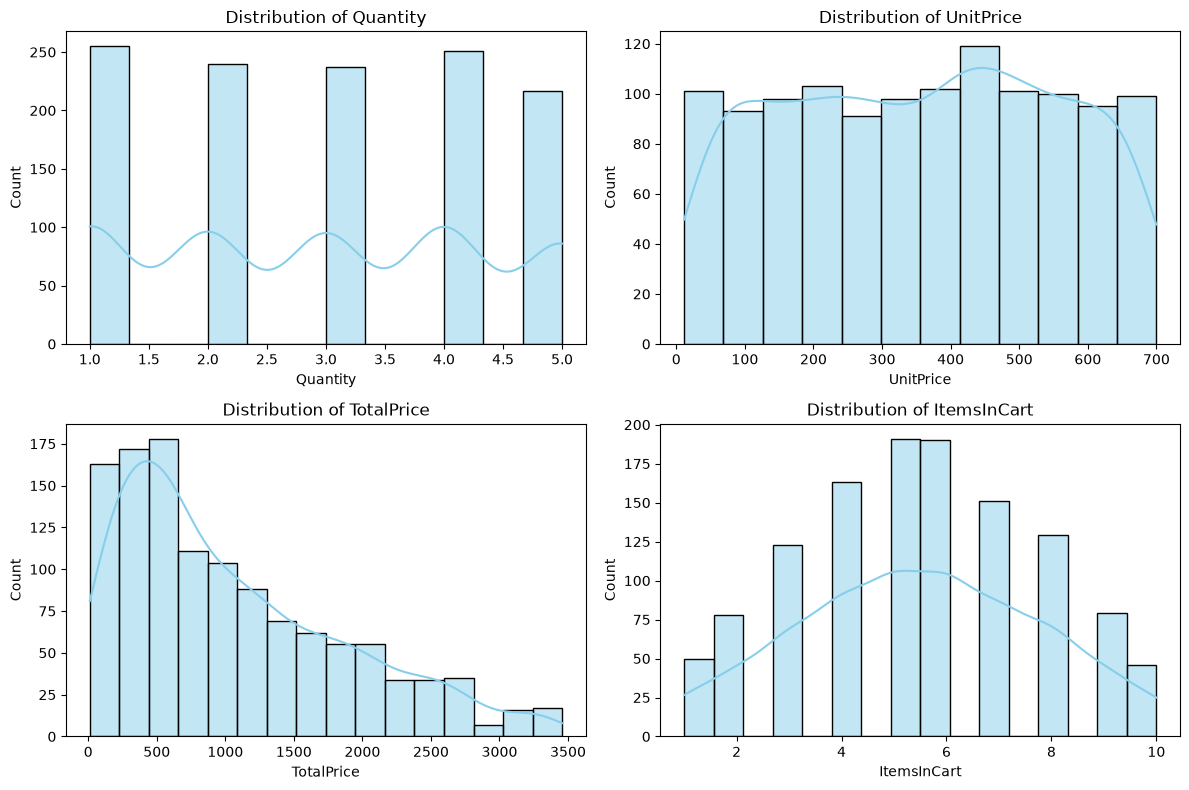

In [ ]:
# Select numeric columns for EDA
numeric_cols = ['Quantity', 'UnitPrice', 'TotalPrice', 'ItemsInCart']

print("="*50)
print("THE FIVE-NUMBER SUMMARY & CENTER OF GRAVITY \nThe Geometry of Distribution (Univariate Analysis)")
print("="*50)

for col in numeric_cols:
    print(f"\n--- {col} ---")
    # Count, Mean, Median (The Center)
    count = df[col].count()
    mean_val = df[col].mean()
    median_val = df[col].median()
    
    # Five-Number Summary
    min_val = df[col].min()
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    max_val = df[col].max()
    
    print(f"Count: {count}")
    print(f"Mean (Average): {mean_val:.2f}")
    print(f"Median (Middle): {median_val:.2f}")
    print(f"Five-Number Summary: Min={min_val}, Q1={q1}, Median={median_val}, Q3={q3}, Max={max_val}")
    
    # Mean vs Median Skewness
    if mean_val > median_val:
        print(f"DIAGNOSIS: Mean > Median. Distribution is RIGHT-SKEWED (driven by high-value outliers).")
    elif mean_val < median_val:
        print(f"DIAGNOSIS: Mean < Median. Distribution is LEFT-SKEWED.")
    else:
        print(f"DIAGNOSIS: Mean ≈ Median. Symmetrical Distribution.")

# Visualize distributions (PDF Page 8)
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i//2, i%2], color='skyblue')
    axes[i//2, i%2].set_title(f'Distribution of {col}')
plt.tight_layout()
plt.show()  


FORENSIC OUTLIER DETECTION 
Unmasking the Outliers (Noise vs. Signal)

🔹 IQR METHOD (Robust):
Lower Fence: -1341.41, Upper Fence: 3330.41
Total Outliers Detected: 8
Percentage of total orders: 0.67%

 Z-SCORE METHOD (Sensitive):
Flagged if |Z| > 3. Outliers Detected: 0


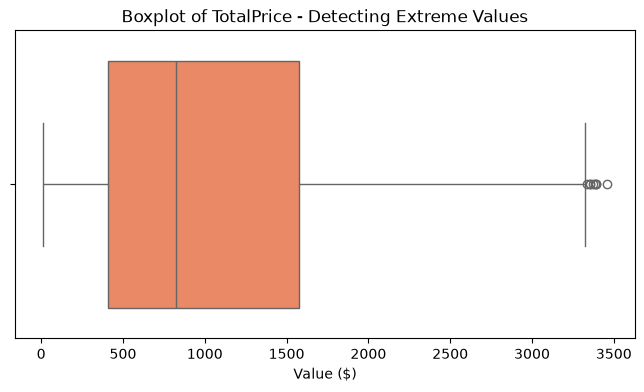


💡 'SO WHAT?' DIAGNOSIS: These 8 outlier orders average $3379.18. 
   This suggests either B2B bulk purchases or premium enterprise clients. 
   Consider a tiered pricing strategy for these high-value segments.


In [12]:
print("="*50)
print("FORENSIC OUTLIER DETECTION \nUnmasking the Outliers (Noise vs. Signal)")
print("="*50)

# Focus on TotalPrice (The main KPI)
col = 'TotalPrice'

# IQR Method
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
print(f"\n🔹 IQR METHOD (Robust):")
print(f"Lower Fence: {lower_bound:.2f}, Upper Fence: {upper_bound:.2f}")
print(f"Total Outliers Detected: {len(outliers_iqr)}")
print(f"Percentage of total orders: {(len(outliers_iqr)/len(df))*100:.2f}%")

# Z-Score Method - assumes near-normal
z_scores = np.abs(stats.zscore(df[col].dropna()))
outliers_z = df[df[col].isin(df[col].iloc[np.where(z_scores > 3)[0]])]
print(f"\n Z-SCORE METHOD (Sensitive):")
print(f"Flagged if |Z| > 3. Outliers Detected: {len(outliers_z)}")

# The Fingerprint of Variability: Boxplot
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[col], color='coral')
plt.title(f'Boxplot of {col} - Detecting Extreme Values')
plt.xlabel('Value ($)')
plt.show()

# diagnosis for the outliers found
if len(outliers_iqr) > 0:
    avg_outlier_value = outliers_iqr[col].mean()
    print(f"\n💡 'SO WHAT?' DIAGNOSIS: These {len(outliers_iqr)} outlier orders average ${avg_outlier_value:.2f}. ")
    print(f"   This suggests either B2B bulk purchases or premium enterprise clients. ")
    print(f"   Consider a tiered pricing strategy for these high-value segments.")

MAPPING RELATIONSHIPS (CORRELATION MATRIX)

Pearson Correlation Coefficient (r):
             Quantity  UnitPrice  TotalPrice  ItemsInCart
Quantity     1.000000   0.014553    0.615251     0.650061
UnitPrice    0.014553   1.000000    0.717081     0.000602
TotalPrice   0.615251   0.717081    1.000000     0.392540
ItemsInCart  0.650061   0.000602    0.392540     1.000000


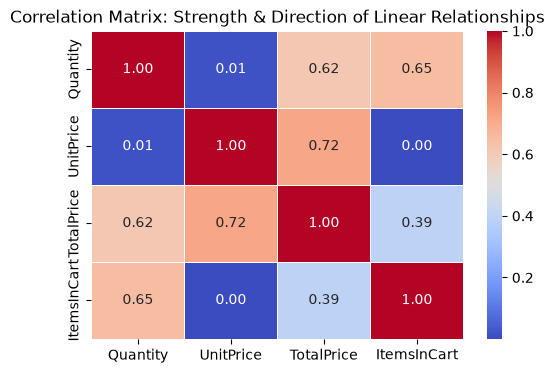


GOLDEN RULE: Correlation ≠ Causation.
If 'ItemsInCart' correlates highly with 'TotalPrice', it's a CLUE, not a VERDICT.
Check if adding more items always increases price, or if high-priced items inflate the cart value.


In [13]:
print("="*50)
print("MAPPING RELATIONSHIPS (CORRELATION MATRIX)")
print("="*50)

# Calculate Pearson Correlation
corr_matrix = df[numeric_cols].corr()

print("\nPearson Correlation Coefficient (r):")
print(corr_matrix)

# Heatmap Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Strength & Direction of Linear Relationships')
plt.show()

# Golden Rule: Correlation ≠ Causation
print("\nGOLDEN RULE: Correlation ≠ Causation.")
print("If 'ItemsInCart' correlates highly with 'TotalPrice', it's a CLUE, not a VERDICT.")
print("Check if adding more items always increases price, or if high-priced items inflate the cart value.")

In [14]:
print("="*50)
print("CATEGORICAL EVIDENCE (Order Status & Channels)")
print("="*50)

# Order Status distribution
print("\n🔹 ORDER FULFILLMENT RATE:")
status_counts = df['OrderStatus'].value_counts()
print(status_counts)
print(f"Delivered/Shipped Rate: {((status_counts.get('Delivered',0) + status_counts.get('Shipped',0)) / len(df)) * 100:.2f}%")

# Revenue by Referral Source
print("\n🔹 MARKETING CHANNEL PERFORMANCE (Revenue):")
channel_revenue = df.groupby('ReferralSource')['TotalPrice'].sum().sort_values(ascending=False)
print(channel_revenue)

# The "So What?" test for Channels
top_channel = channel_revenue.index[0]
print(f"\n 'SO WHAT?' DIAGNOSIS: {top_channel} drives the highest revenue. ")
print("   Shift marketing budget towards this channel. If 'Referral' is top, invest in a referral incentive program.")

CATEGORICAL EVIDENCE (Order Status & Channels)

🔹 ORDER FULFILLMENT RATE:
OrderStatus
Cancelled    250
Returned     247
Pending      237
Shipped      235
Delivered    231
Name: count, dtype: int64
Delivered/Shipped Rate: 38.83%

🔹 MARKETING CHANNEL PERFORMANCE (Revenue):
ReferralSource
Instagram    275285.45
Email        261808.55
Google       250441.48
Facebook     250410.90
Referral     226815.58
Name: TotalPrice, dtype: float64

 'SO WHAT?' DIAGNOSIS: Instagram drives the highest revenue. 
   Shift marketing budget towards this channel. If 'Referral' is top, invest in a referral incentive program.


In [15]:
print("\n" + "="*50)
print("THE VERDICT: EXECUTIVE SUMMARY")
print("="*50)

avg_order_value = df['TotalPrice'].mean()
total_revenue = df['TotalPrice'].sum()
total_orders = len(df)
returned_orders = len(df[df['OrderStatus'] == 'Returned'])
cancelled_orders = len(df[df['OrderStatus'] == 'Cancelled'])

# 1. Problem Statement
print("1. PROBLEM STATEMENT:")
print("   Analyze sales transaction data to identify revenue drivers, detect fulfillment issues, and optimize pricing/campaign strategies.")

# 2. Methodology
print("\n2. METHODOLOGY:")
print("   Data was cleaned and analyzed using the IPO Framework. Univariate analysis (Mean/Median/Skew), IQR outlier detection, Pearson correlation, and categorical aggregation were applied.")

# 3. Key Findings (The strongest signals)
print("\n3. KEY FINDINGS:")
print(f"   - Average Order Value (AOV): ${avg_order_value:.2f}.")
print(f"   - Total Revenue Generated: ${total_revenue:,.2f}.")
print(f"   - Outlier Analysis: {len(outliers_iqr)} extreme high-value orders detected (IQR method).")
print(f"   - Correlation Alert: {numeric_cols[0]} vs {numeric_cols[2]} has r = {corr_matrix.loc['Quantity', 'TotalPrice']:.2f}.")
print(f"   - Operational Risk: {returned_orders + cancelled_orders} orders were not successfully delivered.")

# 4. Recommendations (Actionable Next Steps)
print("\n4. RECOMMENDATIONS:")
print(f"   A) High-Value Segment: Implement a loyalty program for orders > ${upper_bound:.2f}.")
print(f"   B) Fulfillment: Investigate the root cause of the {returned_orders} returned orders (Product quality or Shipping damage?).")
print(f"   C) Marketing: Double down on '{top_channel}' channel to maximize ROI.")


THE VERDICT: EXECUTIVE SUMMARY
1. PROBLEM STATEMENT:
   Analyze sales transaction data to identify revenue drivers, detect fulfillment issues, and optimize pricing/campaign strategies.

2. METHODOLOGY:
   Data was cleaned and analyzed using the IPO Framework. Univariate analysis (Mean/Median/Skew), IQR outlier detection, Pearson correlation, and categorical aggregation were applied.

3. KEY FINDINGS:
   - Average Order Value (AOV): $1053.97.
   - Total Revenue Generated: $1,264,761.96.
   - Outlier Analysis: 8 extreme high-value orders detected (IQR method).
   - Correlation Alert: Quantity vs TotalPrice has r = 0.62.
   - Operational Risk: 497 orders were not successfully delivered.

4. RECOMMENDATIONS:
   A) High-Value Segment: Implement a loyalty program for orders > $3330.41.
   B) Fulfillment: Investigate the root cause of the 247 returned orders (Product quality or Shipping damage?).
   C) Marketing: Double down on 'Instagram' channel to maximize ROI.
